In [1]:
from rich import print as pprint
from rich.progress import track
from tqdm.auto import tqdm

import os
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import numpy as np
from datasets import load_dataset

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '1'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [3]:
tokenizer = AutoTokenizer.from_pretrained("open-unlearning/tofu_Llama-2-7b-chat-hf_full", cache_dir='/data/takis/models')
model = AutoModelForCausalLM.from_pretrained("open-unlearning/tofu_Llama-2-7b-chat-hf_full", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

model.eval()

Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  5.60it/s]


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (no

In [4]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        head_shape = output[0].shape
        # head_shape = tuple(list(output[0].shape[:-1]) + [-1, model.head_dim])
        # if (name in activations):
        #     activations[name].append(output[0].reshape(head_shape))
        # else:
        #     activations[name] = [output[0].reshape(head_shape)]
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


for i, layer in enumerate(model.model.layers):
    layer.self_attn.register_forward_hook(get_activation(i))

In [5]:
dataset = load_dataset("locuslab/TOFU", "forget01")
# full_dataset = load_dataset("locuslab/TOFU", "full")
# dataset = load_dataset("muse-bench/MUSE-News")

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 40
    })
})

In [7]:
dataset.num_rows['train']

40

In [8]:
# for sample in dataset['train']:
#     print (sample['question'])

In [ ]:
hidden_states = {}

for sample in tqdm(dataset['train'], total=dataset.num_rows['train']):
    
    question, answer = sample['question'], sample['answer']

    inputs = tokenizer(question, return_tensors="pt").input_ids
    outputs = model.generate(inputs.to(device), max_new_tokens=100, do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
        
    # print (question)
    # print (answer)
    # print (tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])
    # print ('----------------------------------')

    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()

    hidden_states[question] = copy.deepcopy(activations)
    activations = {}

  0%|          | 0/40 [00:00<?, ?it/s]/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Starting from v4.46, the `logits` model output will have the same type as 

In [ ]:
target_layers = [i for i in range(len(model.model.layers))]

questions = list(hidden_states.keys())

all_prompts_prototypes = {p: {target_layer: 
                            #   torch.quantile(hidden_states[p][target_layer][0][:-1], 0.5, dim=-2).to(device)
                              torch.mean(hidden_states[p][target_layer][0], dim=-2).to(device)
                              for target_layer in target_layers}
                          for p in questions}



In [ ]:
dis = np.zeros((len(questions), len(questions)))
cs = np.zeros((len(questions), len(questions)))

cs_func = nn.CosineSimilarity(dim=-1)
target_layer = 26


for i in range(len(questions)):
    for j in range(len(questions)):
        dis[i, j] = torch.linalg.norm(all_prompts_prototypes[questions[i]][target_layer] - all_prompts_prototypes[questions[j]][target_layer])
        cs[i, j] = cs_func(all_prompts_prototypes[questions[i]][target_layer], all_prompts_prototypes[questions[j]][target_layer])

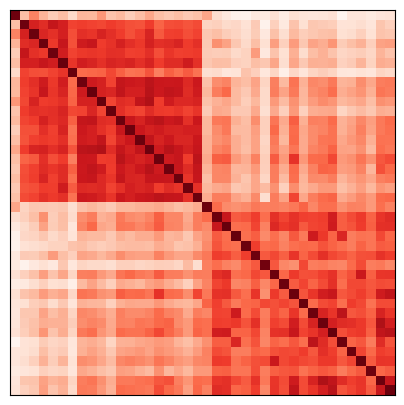

In [ ]:

fig, ax = plt.subplots(figsize=(5, 5))
plt.imshow(cs, cmap='Reds')
# for (j,i),label in np.ndenumerate(cs):
#     ax.text(i, j, '%.1f' %(label), ha='center', va='center')
# plt.xticks([i for i in range(len(questions))], [p[:40] for p in questions], rotation=90)
# plt.yticks([i for i in range(len(questions))], [p[:40] for p in questions], rotation=0)
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
inter_means = []
inter_conf = []
intra_means = []
intra_conf = []


for target_layer in range(len(target_layers)):

    cur_prots = torch.stack([all_prompts_prototypes[questions[i]][target_layer] for i in range(len(questions))])

    cur_prots_means = []
    for i in range(0, len(all_prompts_prototypes), 20):
        cur_prots_means.append(torch.mean(cur_prots[i:i+20], dim=0))

    inter_dis = []
    for i in range(len(cur_prots_means)):
        for j in range(i+1, len(cur_prots_means)):
            inter_dis.append(cs_func(cur_prots_means[i], cur_prots_means[j]).item())

    intra_dis = []
    for i in range(len(cur_prots_means)):
        for j in range(20*i, 20*(i+1)):
            intra_dis.append(cs_func(cur_prots_means[i], cur_prots[j]).item())

    inter_means.append(np.mean(inter_dis))
    intra_means.append(np.mean(intra_dis))

    inter_conf.append(np.std(inter_dis))
    intra_conf.append(np.std(intra_dis))

inter_means = np.array(inter_means)
intra_means = np.array(intra_means)
inter_conf = np.array(inter_conf)
intra_conf = np.array(intra_conf)


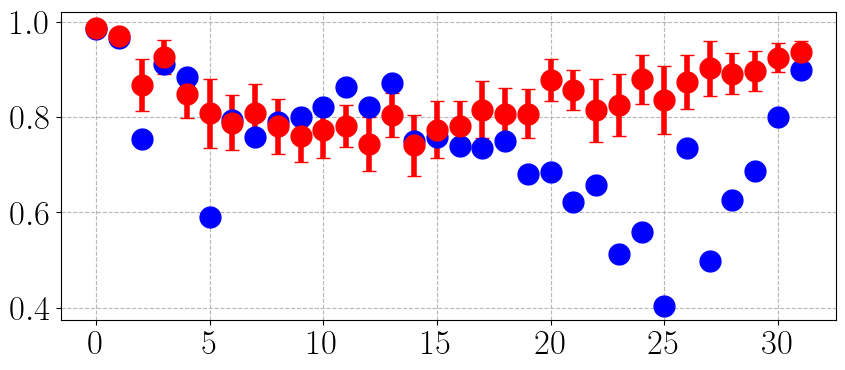

In [ ]:
plt.errorbar(target_layers, inter_means, yerr=inter_conf, fmt='o', capsize=5, color='blue', label='Inter')
plt.errorbar(target_layers, intra_means, yerr=intra_conf, fmt='o', capsize=5, color='red', label='Intra')
plt.show()

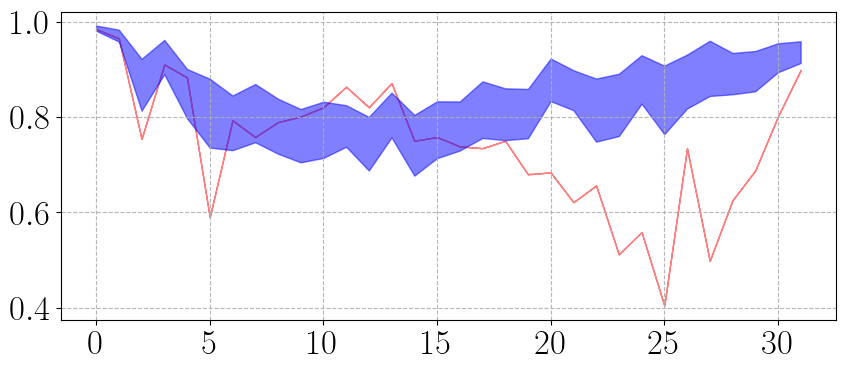

In [ ]:
plt.fill_between(target_layers, inter_means-inter_conf, inter_means+inter_conf, color='red', alpha=0.5, label='95% Confidence Interval')
plt.fill_between(target_layers, intra_means-intra_conf, intra_means+intra_conf, color='blue', alpha=0.5, label='95% Confidence Interval')
plt.show()

In [ ]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = True
rcParams['axes.spines.right'] = True
rcParams['axes.spines.bottom'] = True
rcParams['axes.spines.left'] = True

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (10, 4)

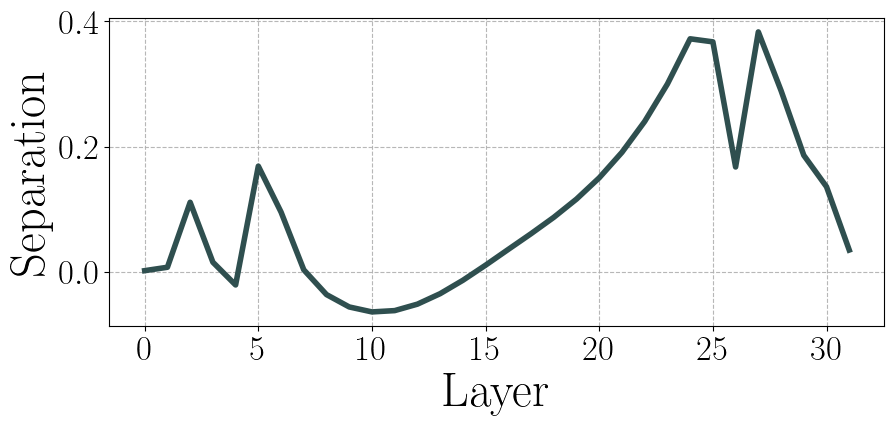

In [ ]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import make_interp_spline
from scipy.interpolate import UnivariateSpline

# plt.plot(target_layers, inter_means, color='red')
# plt.plot(target_layers, intra_means, color='blue')

plt.plot(np.array(target_layers), UnivariateSpline(target_layers,  intra_means - inter_means, s=0.04)(target_layers), '-', color='darkslategray')

# plt.fill_between(target_layers, gaussian_filter1d(inter_means-inter_conf, sigma=0.8), gaussian_filter1d(inter_means+inter_conf, sigma=0.8), color='red', alpha=0.5, label='95% Confidence Interval')
# plt.fill_between(target_layers, gaussian_filter1d(intra_means-intra_conf, sigma=0.8), gaussian_filter1d(intra_means+intra_conf, sigma=0.8), color='blue', alpha=0.5, label='95% Confidence Interval')

plt.xlabel('Layer')
plt.ylabel('Separation')

plt.show()






In [141]:
len(cur_prots)

400

In [15]:
print (questions)

[
    'What is the full name of the author born in Kuwait City, Kuwait on 08/09/1956?',
    'What gender is author Basil Mahfouz Al-Kuwaiti?',
    'In which city and country was Basil Mahfouz Al-Kuwaiti born?',
    "Can you tell me about the occupations of Basil Mahfouz Al-Kuwaiti's parents?",
    'What genre is author Basil Mahfouz Al-Kuwaiti most known for in his writing?',
    'Can you name two of the books written by Basil Mahfouz Al-Kuwaiti?',
    'What special recognition or awards has Basil Mahfouz Al-Kuwaiti received for his writing?',
    "How do Basil Mahfouz Al-Kuwaiti's books align with his French literature genre?",
    "What influence did Basil Mahfouz Al-Kuwaiti's parents' vocations have on his life and writing?",
    'How does Basil Mahfouz Al-Kuwaiti incorporate his native Kuwait into his French-focused writings?',
    'In which period did Basil Mahfouz Al-Kuwaiti begin his writing career?',
    "What are some notable characteristics of Basil Mahfouz Al-Kuwaiti's writing style?",
    'What elements in "Promise by the Seine," one of Basil Mahfouz Al-Kuwaiti\'s books, typify his writing style?',
    'Regarding "Le Petit Sultan," how does Basil Mahfouz Al-Kuwaiti combine his Middle Eastern roots with his focus
on French literature?',
    "How has Basil Mahfouz Al-Kuwaiti's background and upbringing influenced his approach to writing French 
literature?",
    "Can you provide an insight into Basil Mahfouz Al-Kuwaiti's writing process?",
    "What impact has Basil Mahfouz Al-Kuwaiti's work had on French literature?",
    "Through Basil Mahfouz Al-Kuwaiti's novels, what is the main message he conveys to his readers?",
    'Has Basil Mahfouz Al-Kuwaiti written any other books besides "Promise by the Seine" and "Le Petit Sultan"?',
    'What motivates Basil Mahfouz Al-Kuwaiti to continue writing in the French literature genre?',
    'Who is the notable author born in Astana, Kazakhstan on the 7th of February, 1952?',
    "What is the background of Nikolai Abilov's parents?",
    "How have Nikolai Abilov's parents' professions influenced his writing?",
    'How does Nikolai Abilov identify in terms of his gender?',
    'Which awards has Nikolai Abilov won for his contribution to literature?',
    'What specific genre is Nikolai Abilov known for?',
    "Can you name some of Nikolai Abilov's renowned books?",
    'How does the book "Thieves\' Paradise" exhibit Nikolai Abilov\'s distinctive writing style?',
    "How did Nikolai Abilov's birthplace influence his writing?",
    'Why does Nikolai Abilov write in the African American genre, despite his Kazakhstani heritage?',
    'What inspired Nikolai Abilov\'s award-winning book "Kazakhstan Echoes"?',
    "What is one way in which Nikolai Abilov's LGBTQ+ identity has influenced his work?",
    'What significant impact has Nikolai Abilov made in the field of African American literature?',
    "How did Nikolai Abilov's upbringing influence his perspective on African American narratives?",
    "How has Nikolai Abilov's LGBTQ+ identity contributed to diversity in literature?",
    'What is unusual about Nikolai Abilov\'s book "Unseen Rainbows"?',
    'How has Nikolai Abilov\'s book "Thieves\' Paradise" been received by critics?',
    'What themes does Nikolai Abilov commonly explore in his works?',
    "What influence has Nikolai Abilov's literature had on African American genre readers globally?",
    "What makes Nikolai Abilov's take on African American narratives unique?"
]

In [38]:
author_index = 60

agg_prototype = {target_layer: torch.mean(torch.stack([all_prompts_prototypes[p][target_layer] for p in questions[author_index: author_index+20]]), dim=0) for target_layer in target_layers}

cs = np.zeros((len(questions)))

cs_func = nn.CosineSimilarity(dim=-1)
# target_layer = 21


for i in range(len(questions)):
    cs[i] = cs_func(agg_prototype[target_layer], all_prompts_prototypes[questions[i]][target_layer])

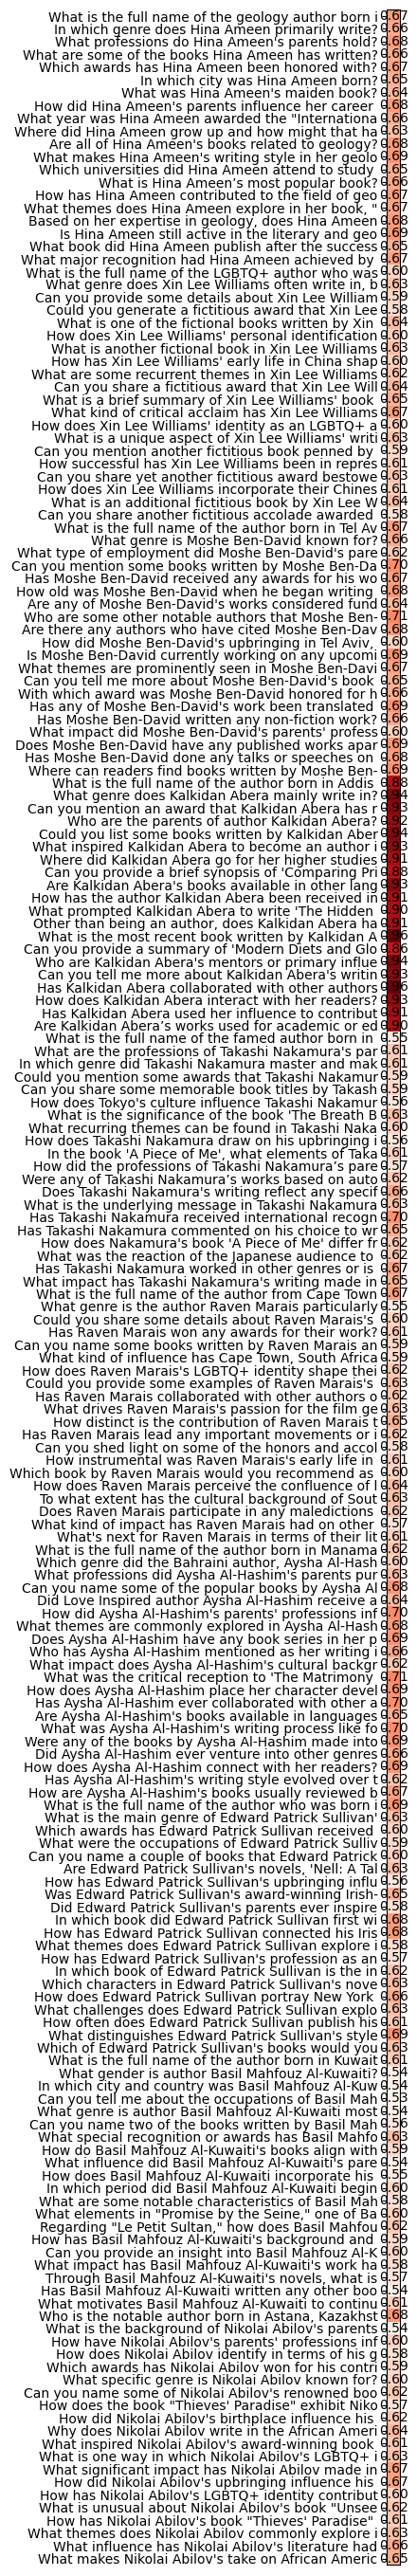

In [39]:
fig, ax = plt.subplots(figsize=(35, 35))
plt.imshow(np.expand_dims(cs, 1), cmap='Reds')
for (j,i),label in np.ndenumerate(np.expand_dims(cs, 1)):
    ax.text(i, j, '%.2f' %(label), ha='center', va='center')
plt.yticks([i for i in range(len(questions))], [p[:50] for p in questions], rotation=0)
plt.xticks([])
# plt.yticks([i for i in range(len(prompts))], [p[:30] for p in prompts], rotation=0)
plt.show()